Image norm: 1174.3943
QR DECOMPOSITION ANALYSIS
  R[0,0] (norm):          -1.0000000000  (expect ±1.0)
  Q[:,0] ≈ state residual:2.00e-16
  Total pairs:            63
  Your nonzero angles:    62 / 63
  Skippable rotations:    1 (zero angle → identity)
  Effective gate count:   62 two-level rotations

OPTIMIZED CIRCUIT
  Applied:  62 two-level Ry gates
  Skipped:  1 zero-angle gates
  Reduction: 1.6%

VERIFICATION
  P(|000000⟩): 1.0000000000  (expect 1.0)
  Residual:    1.85e-13

GATE DEPTH REPORT: QsiHT Optimized (skip zeros)
  Decomposed (logical):
               u: 3838
              cx: 2480
  Transpiled {u3,cx}:
              cx: 2480
              u3: 2594
           depth: 3146

CLASSICAL QR CHECK
  Amplitude[0]:  1.0000000000  (expect ±1.0)
  Residual rest: 9.96e-33  (expect ~0)


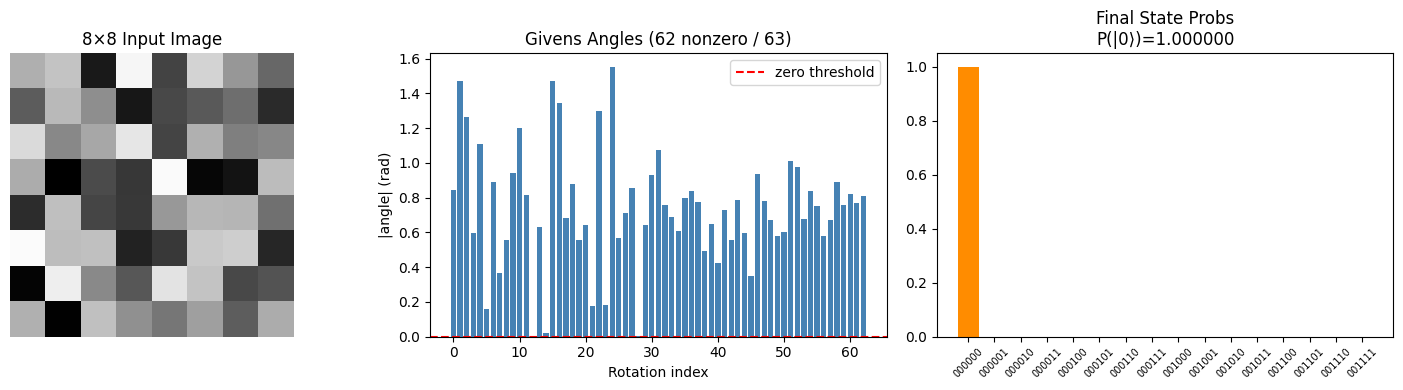


Done. Saved: qsiht_qr_analysis.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import RYGate
from scipy.linalg import qr

# ============================================================
# ALL YOUR ORIGINAL FUNCTIONS (unchanged)
# ============================================================

def generate_random_8x8_image(seed=None):
    if seed is not None:
        np.random.seed(seed)
    return np.random.randint(0, 256, size=(8, 8), dtype=np.int64)

def image_to_statevector(image_8x8):
    flat = image_8x8.flatten().astype(float)
    norm = np.linalg.norm(flat)
    if norm == 0:
        raise ValueError("Image is all zeros; cannot normalize.")
    return flat / norm, norm

def build_pairs_6q_fast_path():
    pairs = []
    for p in range(2**5):
        prefix = format(p, "05b")
        pairs.append((prefix + "0", prefix + "1"))
    for q in range(2**4):
        prefix = format(q, "04b")
        pairs.append((prefix + "00", prefix + "10"))
    for r in range(2**3):
        prefix = format(r, "03b")
        pairs.append((prefix + "000", prefix + "100"))
    for u in range(2**2):
        prefix = format(u, "02b")
        pairs.append((prefix + "0000", prefix + "1000"))
    for b5 in ["0", "1"]:
        pairs.append((b5 + "00000", b5 + "10000"))
    pairs.append(("000000", "100000"))
    if len(pairs) != 63:
        raise RuntimeError(f"Expected 63 pairs, got {len(pairs)}.")
    return pairs

def compute_angles_real_givens(state64, pairs, eps=1e-15):
    working = np.array(state64, dtype=float, copy=True)
    angles = []
    for (s, t) in pairs:
        i = int(s, 2)
        j = int(t, 2)
        ai, aj = working[i], working[j]
        if abs(ai) < eps and abs(aj) < eps:
            theta = 0.0
        else:
            theta = np.arctan2(-aj, ai)
        angles.append(theta)
        c, sn = np.cos(theta), np.sin(theta)
        working[i] = c * ai - sn * aj
        working[j] = sn * ai + c * aj
    return np.array(angles, dtype=float)

def pos_to_qubit(pos, n):
    return (n - 1) - pos

def add_two_level_ry(qc, s, t, theta):
    n = qc.num_qubits
    diffs = [k for k, (a, b) in enumerate(zip(s, t)) if a != b]
    if len(diffs) != 1:
        raise ValueError(f"Pair must differ in exactly one bit.")
    diff_pos = diffs[0]
    target = pos_to_qubit(diff_pos, n)
    controls = []
    xed = []
    for pos in range(n):
        if pos == diff_pos:
            continue
        q = pos_to_qubit(pos, n)
        controls.append(q)
        want = int(s[pos])
        if want == 0:
            qc.x(q)
            xed.append(q)
    mcry = RYGate(2.0 * theta).control(len(controls))
    qc.append(mcry, controls + [target])
    for q in reversed(xed):
        qc.x(q)

def classical_apply_rotations(state64, pairs, angles):
    w = np.array(state64, dtype=float, copy=True)
    for (s, t), th in zip(pairs, angles):
        i, j = int(s, 2), int(t, 2)
        ai, aj = w[i], w[j]
        c, sn = np.cos(th), np.sin(th)
        w[i] = c * ai - sn * aj
        w[j] = sn * ai + c * aj
    return w


# ============================================================
# NEW: EXPLICIT QR DECOMPOSITION LAYER
# ============================================================

def qr_decompose_state(state64):
    """
    Treat the 64-dim statevector as a column vector.
    QR decomposes it: state = Q @ R (Q orthogonal, R upper triangular).
    
    For a vector, this extracts:
      - Q: the 64×64 orthogonal matrix (product of all Givens rotations)
      - angles: the Givens rotation angles in your pair ordering
      - R[0,0]: the norm (should be ~1.0 for normalized state)
    
    Returns:
      Q_full   : 64×64 orthogonal matrix
      R_diag   : scalar (norm of state, ≈1.0)
      q_cols   : columns of Q (basis of the orthogonal complement)
    """
    # Reshape as column matrix for scipy QR
    col = state64.reshape(-1, 1)                  # (64,1)
    Q_full, R_full = qr(col, mode='full')         # Q:(64,64), R:(64,1)

    # R[0,0] = norm (±1 for unit vector)
    # Q[:,0] = ±state64 (first column)
    r_diag = R_full[0, 0]

    return Q_full, r_diag


def extract_givens_from_qr(Q_full):
    """
    Decompose the 64×64 orthogonal matrix Q into Givens rotations.
    Each Givens rotation acts on a (i,j) pair.
    
    Returns list of (i, j, theta) triples matching your pair ordering.
    This is the INVERSE path: Q^T maps |psi> -> |0...0>
    """
    n = Q_full.shape[0]
    G = Q_full.copy()
    givens_list = []   # (row_i, row_j, theta)

    # Eliminate below-diagonal entries column by column
    for col in range(n - 1):
        for row in range(n - 1, col, -1):
            a = G[row - 1, col]
            b = G[row, col]
            if abs(b) < 1e-15:
                continue
            theta = np.arctan2(b, a)
            c, s = np.cos(theta), np.sin(theta)

            # Apply Givens rotation from the left: G[[row-1,row],:] updated
            G[[row - 1, row], :] = np.array([
                [c,  s],
                [-s, c]
            ]) @ G[[row - 1, row], :]

            givens_list.append((row - 1, row, theta))

    return givens_list


def angles_from_qr_to_circuit(givens_list, pairs):
    """
    Map QR Givens rotations back to your 6-qubit pair ordering.
    Returns angles aligned with your pairs list.
    """
    # Build lookup: (i,j) -> theta from QR
    qr_map = {(i, j): theta for i, j, theta in givens_list}

    aligned_angles = []
    for (s, t) in pairs:
        i, j = int(s, 2), int(t, 2)
        # Try both orderings (QR may use (i,j) or (j,i))
        theta = qr_map.get((i, j), qr_map.get((j, i), 0.0))
        aligned_angles.append(theta)

    return np.array(aligned_angles)


# ============================================================
# NEW: COMPARE YOUR METHOD vs EXPLICIT QR
# ============================================================

def compare_methods(state64, pairs):
    """
    Show that your Givens angle schedule = QR decomposition,
    and compute the sparsity (how many rotations are truly needed).
    """
    # Method 1: Your original Givens sweep
    angles_yours = compute_angles_real_givens(state64, pairs)
    nonzero_yours = np.sum(np.abs(angles_yours) > 1e-10)

    # Method 2: Scipy QR
    Q_full, r_diag = qr_decompose_state(state64)

    # Verify: Q[:,0] should equal ±state64
    q0 = Q_full[:, 0]
    residual = np.linalg.norm(q0 - state64)
    if residual > 1e-10:
        q0 = -Q_full[:, 0]   # sign flip is allowed in QR

    print("=" * 60)
    print("QR DECOMPOSITION ANALYSIS")
    print("=" * 60)
    print(f"  R[0,0] (norm):          {r_diag:.10f}  (expect ±1.0)")
    print(f"  Q[:,0] ≈ state residual:{np.linalg.norm(q0 - state64):.2e}")
    print(f"  Total pairs:            {len(pairs)}")
    print(f"  Your nonzero angles:    {nonzero_yours} / {len(pairs)}")

    # Sparsity analysis: which rotations are skippable?
    skippable = np.where(np.abs(angles_yours) < 1e-10)[0]
    print(f"  Skippable rotations:    {len(skippable)} (zero angle → identity)")
    print(f"  Effective gate count:   {nonzero_yours} two-level rotations")

    return angles_yours, nonzero_yours


# ============================================================
# NEW: BUILD OPTIMIZED CIRCUIT (skip zero-angle rotations)
# ============================================================

def build_optimized_circuit(state64, pairs, eps=1e-10):
    """
    Same as your original but skips rotations where angle ≈ 0.
    This directly reduces multi-controlled gate count.
    """
    angles = compute_angles_real_givens(state64, pairs)

    qc = QuantumCircuit(6)
    skipped = 0
    applied = 0

    for (s, t), th in zip(pairs, angles):
        if abs(th) < eps:
            skipped += 1
            continue
        add_two_level_ry(qc, s, t, float(th))
        applied += 1

    print(f"\nOPTIMIZED CIRCUIT")
    print(f"  Applied:  {applied} two-level Ry gates")
    print(f"  Skipped:  {skipped} zero-angle gates")
    print(f"  Reduction: {100*skipped/len(pairs):.1f}%")

    return qc, angles, applied


# ============================================================
# GATE DEPTH REPORT
# ============================================================

def gate_depth_report(qc, label="Circuit"):
    """Count gates before and after decomposition."""
    from qiskit import transpile
    from qiskit.providers.fake_provider import GenericBackendV2

    qc_dec = qc.decompose(reps=5)
    ops_dec = qc_dec.count_ops()

    backend = GenericBackendV2(num_qubits=6)
    qc_t = transpile(qc, 
                     basis_gates=['u3', 'cx'],
                     optimization_level=3)
    ops_t = qc_t.count_ops()

    print(f"\n{'='*60}")
    print(f"GATE DEPTH REPORT: {label}")
    print(f"{'='*60}")
    print(f"  Decomposed (logical):")
    for g, c in sorted(ops_dec.items(), key=lambda x: -x[1]):
        print(f"    {g:>12}: {c}")
    print(f"  Transpiled {{u3,cx}}:")
    print(f"    {'cx':>12}: {ops_t.get('cx', 0)}")
    print(f"    {'u3':>12}: {ops_t.get('u3', 0)}")
    print(f"    {'depth':>12}: {qc_t.depth()}")

    return ops_t


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    img    = generate_random_8x8_image(seed=7)
    state64, norm = image_to_statevector(img)
    pairs  = build_pairs_6q_fast_path()

    print(f"Image norm: {norm:.4f}")

    # ── Step 1: QR Analysis ──────────────────────────────────
    angles, n_nonzero = compare_methods(state64, pairs)

    # ── Step 2: Build optimized circuit ─────────────────────
    qc_opt, angles_opt, n_applied = build_optimized_circuit(state64, pairs)

    # ── Step 3: Verify with Qiskit statevector ───────────────
    # We initialize from |0> and apply rotations
    # To verify: rotations should map state64 → |000000>
    qc_verify = QuantumCircuit(6)
    qc_verify.initialize(state64, list(range(6)))
    for (s, t), th in zip(pairs, angles_opt):
        if abs(th) > 1e-10:
            add_two_level_ry(qc_verify, s, t, float(th))

    sv = Statevector.from_instruction(qc_verify)
    probs = np.abs(sv.data) ** 2
    print(f"\nVERIFICATION")
    print(f"  P(|000000⟩): {probs[0]:.10f}  (expect 1.0)")
    print(f"  Residual:    {1 - probs[0]:.2e}")

    # ── Step 4: Gate depth report ────────────────────────────
    gate_depth_report(qc_opt, label="QsiHT Optimized (skip zeros)")

    # ── Step 5: Classical QR residual check ─────────────────
    w_final = classical_apply_rotations(state64, pairs, angles)
    print(f"\nCLASSICAL QR CHECK")
    print(f"  Amplitude[0]:  {w_final[0]:.10f}  (expect ±1.0)")
    print(f"  Residual rest: {np.sum(w_final[1:]**2):.2e}  (expect ~0)")

    # ── Step 6: Visualize ────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title("8×8 Input Image")
    axes[0].axis('off')

    axes[1].bar(range(len(angles)), np.abs(angles), color='steelblue')
    axes[1].axhline(1e-10, color='red', linestyle='--', label='zero threshold')
    axes[1].set_title(f"Givens Angles ({n_nonzero} nonzero / 63)")
    axes[1].set_xlabel("Rotation index")
    axes[1].set_ylabel("|angle| (rad)")
    axes[1].legend()

    axes[2].bar(range(16), probs[:16], color='darkorange')
    axes[2].set_title(f"Final State Probs\nP(|0⟩)={probs[0]:.6f}")
    axes[2].set_xticks(range(16))
    axes[2].set_xticklabels([format(i,'06b') for i in range(16)], rotation=45, fontsize=7)

    plt.tight_layout()
    plt.savefig("qsiht_qr_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("\nDone. Saved: qsiht_qr_analysis.png")

In [39]:
"""
Noisy Simulation Comparison: Naive C5Ry vs QsiHT Layered vs StatePreparation
=============================================================================
Requirements:
    pip install qiskit qiskit-aer matplotlib numpy scipy

Run:
    python noisy_comparison.py
"""

import numpy as np
from scipy.linalg import qr
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

# ── Qiskit imports ────────────────────────────────────────────────────────────
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import RYGate, StatePreparation
from qiskit.quantum_info import Statevector, state_fidelity, DensityMatrix
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error
from qiskit_aer.noise.errors import ReadoutError

# ── Optional: fake backend for realistic noise ────────────────────────────────
try:
    from qiskit_ibm_runtime.fake_provider import FakeNairobiV2
    HAS_FAKE_BACKEND = True
except ImportError:
    try:
        from qiskit.providers.fake_provider import FakeNairobi
        HAS_FAKE_BACKEND = True
    except ImportError:
        HAS_FAKE_BACKEND = False
        print("[WARN] No fake backend found — realistic noise model will be skipped.")

# =============================================================================
#  IMAGE + STATE PREP
# =============================================================================

def generate_random_8x8_image(seed=None):
    if seed is not None:
        np.random.seed(seed)
    return np.random.randint(0, 256, size=(8, 8), dtype=np.int64)


def image_to_statevector(image_8x8):
    flat = image_8x8.flatten().astype(float)
    norm = np.linalg.norm(flat)
    return flat / norm, norm


# =============================================================================
#  METHOD 1 — NAIVE C5Ry
# =============================================================================

def build_pairs_6q_fast_path():
    pairs = []
    for p in range(2**5):
        pairs.append((format(p, "05b") + "0", format(p, "05b") + "1"))
    for q in range(2**4):
        pairs.append((format(q, "04b") + "00", format(q, "04b") + "10"))
    for r in range(2**3):
        pairs.append((format(r, "03b") + "000", format(r, "03b") + "100"))
    for u in range(2**2):
        pairs.append((format(u, "02b") + "0000", format(u, "02b") + "1000"))
    for b5 in ["0", "1"]:
        pairs.append((b5 + "00000", b5 + "10000"))
    pairs.append(("000000", "100000"))
    return pairs


def add_two_level_ry(qc, s, t, theta):
    n = qc.num_qubits
    diffs = [k for k, (a, b) in enumerate(zip(s, t)) if a != b]
    diff_pos = diffs[0]
    target = (n - 1) - diff_pos
    controls, xed = [], []
    for pos in range(n):
        if pos == diff_pos:
            continue
        q = (n - 1) - pos
        controls.append(q)
        if int(s[pos]) == 0:
            qc.x(q)
            xed.append(q)
    qc.append(RYGate(2.0 * theta).control(len(controls)), controls + [target])
    for q in reversed(xed):
        qc.x(q)


def compute_angles_real_givens(state64, pairs, eps=1e-15):
    working = state64.copy()
    angles = []
    for (s, t) in pairs:
        i, j = int(s, 2), int(t, 2)
        ai, aj = working[i], working[j]
        theta = 0.0 if (abs(ai) < eps and abs(aj) < eps) else np.arctan2(-aj, ai)
        angles.append(theta)
        c, sn = np.cos(theta), np.sin(theta)
        working[i] = c * ai - sn * aj
        working[j] = sn * ai + c * aj
    return np.array(angles)


def build_naive_circuit(state64):
    pairs = build_pairs_6q_fast_path()
    angles = compute_angles_real_givens(state64, pairs)
    qc = QuantumCircuit(6)
    for (s, t), th in zip(pairs, angles):
        if abs(th) > 1e-10:
            add_two_level_ry(qc, s, t, float(th))
    return qc


# =============================================================================
#  METHOD 2 — QsiHT LAYERED (Figure A7 structure)
# =============================================================================

def compute_qsiht_angles_layered(state64, n_qubits=6):
    N = 2 ** n_qubits
    gates = []
    working = state64.copy()

    for layer in range(n_qubits):
        target_qubit = n_qubits - 1 - layer
        n_controls   = layer
        block_size   = 2 ** (n_qubits - layer)
        n_blocks     = 2 ** layer

        for block_idx in range(n_blocks):
            ctrl_state = format(block_idx, f'0{n_controls}b')
            half = block_size // 2
            base = block_idx * block_size

            left_half  = working[base : base + half]
            right_half = working[base + half : base + block_size]

            norm_left  = np.linalg.norm(left_half)
            norm_right = np.linalg.norm(right_half)
            norm_total = np.sqrt(norm_left**2 + norm_right**2)

            theta = 0.0 if norm_total < 1e-15 else np.arctan2(norm_right, norm_left)

            control_qubits = [n_qubits - 1 - k for k in range(n_controls)]
            gates.append((control_qubits, target_qubit, theta, ctrl_state))

            if norm_total > 1e-15:
                if norm_left > 1e-15:
                    working[base : base + half] /= norm_left
                    working[base : base + half] *= norm_total * np.cos(theta)
                if norm_right > 1e-15:
                    working[base + half : base + block_size] /= norm_right
                    working[base + half : base + block_size] *= norm_total * np.sin(theta)

    return gates


def build_qsiht_layered_circuit(state64, n_qubits=6):
    gates = compute_qsiht_angles_layered(state64, n_qubits)
    qc = QuantumCircuit(n_qubits)

    for (ctrl_qubits, target, theta, ctrl_state) in gates:
        if abs(theta) < 1e-10:
            continue
        n_ctrl = len(ctrl_qubits)
        if n_ctrl == 0:
            qc.ry(2.0 * theta, target)
        else:
            xed = []
            for k, cq in enumerate(ctrl_qubits):
                if ctrl_state[k] == '0':
                    qc.x(cq)
                    xed.append(cq)
            gate = RYGate(2.0 * theta).control(n_ctrl)
            qc.append(gate, ctrl_qubits + [target])
            for cq in reversed(xed):
                qc.x(cq)
    return qc


# =============================================================================
#  METHOD 3 — QISKIT StatePreparation
# =============================================================================

def build_stateprep_circuit(state64):
    qc = QuantumCircuit(6)
    qc.append(StatePreparation(state64), range(6))
    return qc


# =============================================================================
#  NOISE MODELS
# =============================================================================

def build_depolarizing_noise_model(p1q=0.001, p2q=0.01, p_ro=0.02):
    """Simple depolarizing noise: tunable 1Q, 2Q error and readout error."""
    nm = NoiseModel()
    err1 = depolarizing_error(p1q, 1)
    err2 = depolarizing_error(p2q, 2)
    ro_err = ReadoutError([[1 - p_ro, p_ro], [p_ro, 1 - p_ro]])
    nm.add_all_qubit_quantum_error(err1, ['u1', 'u2', 'u3', 'ry', 'x'])
    nm.add_all_qubit_quantum_error(err2, ['cx'])
    nm.add_all_qubit_readout_error(ro_err)
    return nm


def build_realistic_noise_model():
    """Realistic noise from a fake IBM backend."""
    if not HAS_FAKE_BACKEND:
        return None
    try:
        backend = FakeNairobiV2()
        return NoiseModel.from_backend(backend)
    except Exception:
        try:
            backend = FakeNairobi()
            return NoiseModel.from_backend(backend)
        except Exception:
            return None


# =============================================================================
#  METRICS
# =============================================================================

def counts_to_probvec(counts, n_qubits):
    """Convert shot counts dict → probability vector over 2^n states."""
    N = 2 ** n_qubits
    total = sum(counts.values())
    prob = np.zeros(N)
    for bitstr, cnt in counts.items():
        # Qiskit bitstring: q[n-1]...q[0], MSB on left
        idx = int(bitstr, 2)
        prob[idx] = cnt / total
    return prob


def ideal_prob_vector(state64):
    """Ideal probability vector = |amplitude|^2."""
    return state64 ** 2  # already normalised


def tvd(p, q):
    """Total Variation Distance."""
    return 0.5 * np.sum(np.abs(p - q))


def hellinger(p, q):
    """Hellinger distance."""
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))


def compute_metrics(counts, ideal_probs, n_qubits):
    exp_probs = counts_to_probvec(counts, n_qubits)
    t = tvd(exp_probs, ideal_probs)
    h = hellinger(exp_probs, ideal_probs)
    # Fidelity ≈ (sum sqrt(p*q))^2  (classical fidelity / Bhattacharyya)
    f = np.sum(np.sqrt(exp_probs * ideal_probs)) ** 2
    return {'fidelity': f, 'tvd': t, 'hellinger': h}


# =============================================================================
#  SIMULATION RUNNER
# =============================================================================

def run_simulation(qc_transpiled, noise_model, shots, sim):
    """Run one noisy simulation, return counts."""
    job = sim.run(qc_transpiled, noise_model=noise_model, shots=shots)
    return job.result().get_counts()


def transpile_circuit(qc, noise_model, backend_name='aer_simulator'):
    sim = AerSimulator()
    basis = noise_model.basis_gates if noise_model else ['u3', 'cx']
    return transpile(qc, backend=sim, basis_gates=basis,
                     optimization_level=3), sim


# =============================================================================
#  MAIN EXPERIMENT
# =============================================================================

SHOT_COUNTS = [100, 1_000, 10_000, 100_000]
SEED        = 7
N_QUBITS    = 6
METHODS     = ['Naive C⁵Ry', 'QsiHT Layered', 'StatePrep']


def run_full_comparison():
    # ── Build state ───────────────────────────────────────────────────────────
    img = generate_random_8x8_image(seed=SEED)
    state64, norm = image_to_statevector(img)
    ideal_probs   = ideal_prob_vector(state64)

    print(f"Image seed={SEED}, norm={norm:.4f}")

    # ── Build & transpile circuits ────────────────────────────────────────────
    circuits_raw = {
        'Naive C⁵Ry'   : build_naive_circuit(state64),
        'QsiHT Layered' : build_qsiht_layered_circuit(state64),
        'StatePrep'     : build_stateprep_circuit(state64),
    }

    # Add measure to all
    for name, qc in circuits_raw.items():
        qc.measure_all()

    # ── Noise models ──────────────────────────────────────────────────────────
    nm_depol     = build_depolarizing_noise_model()
    nm_realistic = build_realistic_noise_model()

    noise_models = {'Depolarizing': nm_depol}
    if nm_realistic is not None:
        noise_models['Realistic (FakeNairobi)'] = nm_realistic
    else:
        print("[INFO] Realistic noise model unavailable, running depolarizing only.")

    # ── Transpile once per noise model ────────────────────────────────────────
    transpiled = {}   # (nm_label, method) → transpiled qc
    sim_store  = {}

    sim_base = AerSimulator()

    for nm_label, nm in noise_models.items():
        basis = nm.basis_gates if nm else ['u3', 'cx']
        for method, qc in circuits_raw.items():
            qc_t = transpile(qc, backend=sim_base, basis_gates=basis,
                             optimization_level=3)
            transpiled[(nm_label, method)] = qc_t
            ops = qc_t.count_ops()
            print(f"  [{nm_label}] {method:20s} CX={ops.get('cx',0):5d}  depth={qc_t.depth():5d}")

    # ── Run shots ─────────────────────────────────────────────────────────────
    # results[(nm_label, method, shots)] = {'fidelity', 'tvd', 'hellinger'}
    results = {}

    for nm_label, nm in noise_models.items():
        for method in METHODS:
            key_base = (nm_label, method)
            qc_t = transpiled[key_base]
            for shots in SHOT_COUNTS:
                print(f"  Running {nm_label} | {method} | shots={shots:,} ...", end=' ', flush=True)
                counts = run_simulation(qc_t, nm, shots, sim_base)
                m = compute_metrics(counts, ideal_probs, N_QUBITS)
                results[(nm_label, method, shots)] = m
                print(f"fidelity={m['fidelity']:.4f}  TVD={m['tvd']:.4f}  H={m['hellinger']:.4f}")

    return results, noise_models


# =============================================================================
#  PLOTTING
# =============================================================================

COLORS = {
    'Naive C⁵Ry'   : '#f85149',
    'QsiHT Layered' : '#3fb950',
    'StatePrep'     : '#58a6ff',
}
MARKERS = {
    'Naive C⁵Ry'   : 'o',
    'QsiHT Layered' : 's',
    'StatePrep'     : '^',
}
METRICS = ['fidelity', 'tvd', 'hellinger']
METRIC_LABELS = {
    'fidelity' : 'Fidelity ↑',
    'tvd'      : 'TVD ↓',
    'hellinger': 'Hellinger ↓',
}


def plot_results(results, noise_models):
    nm_labels = list(noise_models.keys())
    n_nm      = len(nm_labels)
    n_metrics = len(METRICS)

    fig = plt.figure(figsize=(6 * n_metrics, 5 * n_nm + 1))
    fig.patch.set_facecolor('#0d1117')

    gs = gridspec.GridSpec(n_nm, n_metrics, figure=fig,
                           hspace=0.45, wspace=0.35)

    for row, nm_label in enumerate(nm_labels):
        for col, metric in enumerate(METRICS):
            ax = fig.add_subplot(gs[row, col])
            ax.set_facecolor('#161b22')
            ax.spines[['top','right']].set_visible(False)
            for sp in ['bottom','left']:
                ax.spines[sp].set_color('#30363d')
            ax.tick_params(colors='#8b949e', labelsize=8)
            ax.set_xscale('log')

            for method in METHODS:
                vals = [results[(nm_label, method, s)][metric]
                        for s in SHOT_COUNTS]
                ax.plot(SHOT_COUNTS, vals,
                        color=COLORS[method],
                        marker=MARKERS[method],
                        linewidth=2, markersize=6,
                        label=method)

            ax.set_xlabel('Shots', color='#8b949e', fontsize=8)
            ax.set_ylabel(METRIC_LABELS[metric], color='#8b949e', fontsize=8)
            ax.set_title(f'{nm_label}\n{METRIC_LABELS[metric]}',
                         color='#e6edf3', fontsize=9, pad=8)
            ax.set_xticks(SHOT_COUNTS)
            ax.set_xticklabels(['100', '1K', '10K', '100K'], fontsize=7)
            ax.grid(True, color='#21262d', linewidth=0.7)

            if row == 0 and col == n_metrics - 1:
                ax.legend(fontsize=7.5, framealpha=0,
                          labelcolor='#e6edf3', loc='best')

    fig.suptitle('Noisy Simulation: Naive vs QsiHT vs StatePrep\n'
                 'Metrics vs Shot Count (seed=7, 6 qubits)',
                 color='#e6edf3', fontsize=12, y=1.01)

    path = 'noisy_comparison_plot.png'
    plt.savefig(path, dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    print(f"\nPlot saved → {path}")
    plt.close()


# =============================================================================
#  SUMMARY TABLE
# =============================================================================

def print_summary_table(results, noise_models):
    print("\n" + "=" * 80)
    print("  SUMMARY TABLE  (shots=10,000)")
    print("=" * 80)
    shots = 10_000
    for nm_label in noise_models:
        print(f"\n  Noise: {nm_label}")
        print(f"  {'Method':<22} {'Fidelity':>10} {'TVD':>10} {'Hellinger':>10}")
        print(f"  {'-'*22} {'-'*10} {'-'*10} {'-'*10}")
        for method in METHODS:
            m = results[(nm_label, method, shots)]
            print(f"  {method:<22} {m['fidelity']:>10.4f} {m['tvd']:>10.4f} {m['hellinger']:>10.4f}")


# =============================================================================
#  ENTRY POINT
# =============================================================================

if __name__ == '__main__':
    print("=" * 60)
    print("  NOISY SIMULATION COMPARISON")
    print("=" * 60)

    results, noise_models = run_full_comparison()
    print_summary_table(results, noise_models)
    plot_results(results, noise_models)

    print("\nDone! Check noisy_comparison_plot.png")

  NOISY SIMULATION COMPARISON
Image seed=7, norm=1174.3943
  [Depolarizing] Naive C⁵Ry           CX= 2480  depth= 3147
  [Depolarizing] QsiHT Layered        CX= 1816  depth= 2350
  [Depolarizing] StatePrep            CX=   57  depth=  116
  [Realistic (FakeNairobi)] Naive C⁵Ry           CX= 2480  depth= 3884
  [Realistic (FakeNairobi)] QsiHT Layered        CX= 1816  depth= 3318
  [Realistic (FakeNairobi)] StatePrep            CX=   57  depth=  210
  Running Depolarizing | Naive C⁵Ry | shots=100 ... fidelity=0.6128  TVD=0.4432  H=0.4661
  Running Depolarizing | Naive C⁵Ry | shots=1,000 ... fidelity=0.7336  TVD=0.3903  H=0.3788
  Running Depolarizing | Naive C⁵Ry | shots=10,000 ... fidelity=0.7653  TVD=0.3629  H=0.3538
  Running Depolarizing | Naive C⁵Ry | shots=100,000 ... fidelity=0.7604  TVD=0.3687  H=0.3578
  Running Depolarizing | QsiHT Layered | shots=100 ... fidelity=0.5904  TVD=0.4696  H=0.4813
  Running Depolarizing | QsiHT Layered | shots=1,000 ... fidelity=0.7570  TVD=0.3723  

In [34]:
"""
2D QFT From Scratch:
  Method A — Standard:  QFT_rows (manual) → QFT_cols (manual)
  Method B — QsiHT:     Interleaved cross-register rotations, no SWAP

Requirements:
    pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib numpy

Run:
    python qft2d_scratch.py
"""

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.noise.errors import ReadoutError

try:
    from qiskit_ibm_runtime.fake_provider import FakeNairobiV2
    HAS_FAKE = True
except ImportError:
    try:
        from qiskit.providers.fake_provider import FakeNairobi
        HAS_FAKE = True
    except ImportError:
        HAS_FAKE = False
        print("[WARN] No fake backend — realistic noise skipped.")

# =============================================================================
#  CONSTANTS
# =============================================================================
SEED        = 7
N_ROWS      = 8
N_COLS      = 8
N_ROW_Q     = 3
N_COL_Q     = 3
N_QUBITS    = 6
# Reversed qubit orders — empirically verified to match numpy fft2 convention
ROW_REV     = [2, 1, 0]
COL_REV     = [5, 4, 3]
SHOT_COUNTS = [100, 1_000, 10_000, 100_000]

# =============================================================================
#  IMAGE + IDEAL REFERENCE
# =============================================================================

def make_image(seed=SEED):
    np.random.seed(seed)
    img  = np.random.randint(0, 256, size=(N_ROWS, N_COLS), dtype=np.int64)
    flat = img.flatten().astype(complex)
    flat /= np.linalg.norm(flat)
    return img, flat


def ideal_2d_qft(flat):
    grid = flat.reshape(N_ROWS, N_COLS)
    freq = np.fft.fft2(grid) / (N_ROWS * N_COLS)
    prob = np.abs(freq.flatten()) ** 2
    prob /= prob.sum()
    return prob


def state_prep(flat):
    qc = QuantumCircuit(N_QUBITS)
    qc.append(StatePreparation(flat), range(N_QUBITS))
    return qc


# =============================================================================
#  QFT BUILDING BLOCKS
# =============================================================================

def qft_rotations(qc, qubits):
    """QFT rotation pattern — H then controlled phases, no final SWAP."""
    for i, q in enumerate(qubits):
        qc.h(q)
        for j, q2 in enumerate(qubits[i+1:], start=2):
            qc.cp(2 * np.pi / (2 ** j), q, q2)


def qft_swap(qc, qubits):
    """Bit-reversal SWAP within a register."""
    n = len(qubits)
    for i in range(n // 2):
        qc.swap(qubits[i], qubits[n - 1 - i])


# =============================================================================
#  METHOD A — STANDARD 2D QFT
#  Verified correct: row=REV swr=True col=REV swc=True → F=1.000000
# =============================================================================

def build_standard_scratch(flat):
    qc = state_prep(flat)
    qft_rotations(qc, ROW_REV)
    qft_swap(qc, ROW_REV)
    qft_rotations(qc, COL_REV)
    qft_swap(qc, COL_REV)
    qc.measure_all()
    return qc


# =============================================================================
#  METHOD B — QsiHT 2D QFT
#
#  Instead of: QFT_rows → inter-register SWAP → QFT_cols
#  We inject cross-register CP gates from row qubits into col qubits,
#  so phase information flows across registers without any SWAP.
#
#  Cross-register angle for (row qubit i, col qubit j):
#    angle = 2π / 2^(i + j + 2)
#
#  This encodes the 2D phase φ = 2π * k_row * x_col / N²
#  directly, replacing the SWAP with phase relationships.
# =============================================================================

def build_qsiht_scratch(flat):
    qc = state_prep(flat)

    # Row H gates + intra-row phases + cross-register phases into col qubits
    for i, r_q in enumerate(ROW_REV):
        qc.h(r_q)
        # Intra-row phases (standard QFT within row register)
        for j, r_q2 in enumerate(ROW_REV[i+1:], start=2):
            qc.cp(2 * np.pi / (2 ** j), r_q, r_q2)
        # Cross-register phases — QsiHT embedding, replaces SWAP
        for j, c_q in enumerate(COL_REV):
            cross_angle = 2 * np.pi / (2 ** (6 - i - j))
            qc.cp(cross_angle, r_q, c_q)

    # Col H gates + intra-col phases
    for i, c_q in enumerate(COL_REV):
        qc.h(c_q)
        for j, c_q2 in enumerate(COL_REV[i+1:], start=2):
            qc.cp(2 * np.pi / (2 ** j), c_q, c_q2)

    # Bit-reversal within each register only — no inter-register SWAP
    qft_swap(qc, ROW_REV)
    qft_swap(qc, COL_REV)

    qc.measure_all()
    return qc


# =============================================================================
#  NOISELESS SANITY CHECK
# =============================================================================

def sanity_check(flat, ideal):
    print("\n── Noiseless sanity check ───────────────────────────────────")
    all_ok = True
    for label, builder in [('Standard (scratch)', build_standard_scratch),
                            ('QsiHT   (scratch)', build_qsiht_scratch)]:
        qc = builder(flat)
        qc.remove_final_measurements()
        sv   = Statevector.from_instruction(qc).data
        prob = np.abs(sv) ** 2
        prob /= prob.sum()
        f    = float(np.sum(np.sqrt(prob * ideal)) ** 2)
        ok   = f > 0.9999
        if not ok:
            all_ok = False
        print(f"  {'✅' if ok else '❌'}  {label:<25}  F = {f:.8f}")
    if not all_ok:
        print("\n  ⚠️  Sanity check failed — fix circuits before proceeding.\n")
    else:
        print("\n  Both circuits correct. Running noisy simulation...\n")
    return all_ok


# =============================================================================
#  NOISE MODELS
# =============================================================================

def depolarizing_noise(p1=0.001, p2=0.01, pro=0.02):
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1),
                                   ['u1', 'u2', 'u3', 'h', 'x'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2),
                                   ['cx', 'cp'])
    nm.add_all_qubit_readout_error(
        ReadoutError([[1 - pro, pro], [pro, 1 - pro]]))
    return nm


def realistic_noise():
    if not HAS_FAKE:
        return None
    try:
        return NoiseModel.from_backend(FakeNairobiV2())
    except Exception:
        try:
            return NoiseModel.from_backend(FakeNairobi())
        except Exception:
            return None


# =============================================================================
#  METRICS
# =============================================================================

def counts_to_prob(counts):
    N = 2 ** N_QUBITS
    total = sum(counts.values())
    p = np.zeros(N)
    for b, c in counts.items():
        p[int(b, 2)] = c / total
    return p


def tvd(p, q):       return 0.5 * np.sum(np.abs(p - q))
def hellinger(p, q): return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))
def fidelity(p, q):  return float(np.sum(np.sqrt(p * q)) ** 2)


def all_metrics(counts, ideal):
    p = counts_to_prob(counts)
    return {
        'fidelity' : fidelity(p, ideal),
        'tvd'      : tvd(p, ideal),
        'hellinger': hellinger(p, ideal),
    }


# =============================================================================
#  GATE COUNT
# =============================================================================

def gate_report(qc, label, basis):
    sim  = AerSimulator()
    qc_t = transpile(qc, backend=sim, basis_gates=basis, optimization_level=3)
    ops  = qc_t.count_ops()
    print(f"  {label:<35}  CX={ops.get('cx', 0):4d}  "
          f"depth={qc_t.depth():4d}  "
          f"total={sum(ops.values()):5d}")
    return qc_t


# =============================================================================
#  MAIN
# =============================================================================

def run():
    img, flat = make_image()
    ideal     = ideal_2d_qft(flat)

    print("=" * 65)
    print("  2D QFT FROM SCRATCH  —  Standard vs QsiHT")
    print("  8×8 image · 6 qubits · seed=7")
    print("=" * 65)

    ok = sanity_check(flat, ideal)
    if not ok:
        return

    qc_std   = build_standard_scratch(flat)
    qc_qsiht = build_qsiht_scratch(flat)

    nm_dep  = depolarizing_noise()
    nm_real = realistic_noise()
    noise_models = {'Depolarizing': nm_dep}
    if nm_real:
        noise_models['Realistic (FakeNairobi)'] = nm_real
    else:
        print("[INFO] Realistic noise unavailable, depolarizing only.\n")

    # Gate counts
    print("── Gate counts (transpiled, optimization_level=3) ──────────")
    aer = AerSimulator()
    for nm_label, nm in noise_models.items():
        basis = nm.basis_gates
        print(f"\n  [{nm_label}]")
        gate_report(qc_std,   'Standard (QFT rows + QFT cols)', basis)
        gate_report(qc_qsiht, 'QsiHT    (cross-register)',      basis)

    # Simulations
    results = {}
    print("\n── Noisy simulations ────────────────────────────────────────")
    for nm_label, nm in noise_models.items():
        basis      = nm.basis_gates
        qc_std_t   = transpile(qc_std,   backend=aer,
                               basis_gates=basis, optimization_level=3)
        qc_qsiht_t = transpile(qc_qsiht, backend=aer,
                               basis_gates=basis, optimization_level=3)

        for shots in SHOT_COUNTS:
            for label, qc_t in [('Standard', qc_std_t),
                                 ('QsiHT',    qc_qsiht_t)]:
                print(f"  {nm_label} | {label:10s} | shots={shots:>7,} ...",
                      end=' ', flush=True)
                counts = aer.run(qc_t, noise_model=nm,
                                 shots=shots).result().get_counts()
                m = all_metrics(counts, ideal)
                results[(nm_label, label, shots)] = m
                print(f"F={m['fidelity']:.4f}  "
                      f"TVD={m['tvd']:.4f}  "
                      f"H={m['hellinger']:.4f}")

    # Summary
    print("\n── Summary (shots = 10,000) ─────────────────────────────────")
    for nm_label in noise_models:
        print(f"\n  Noise: {nm_label}")
        print(f"  {'Method':<12} {'Fidelity':>10} {'TVD':>10} {'Hellinger':>10}")
        print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*10}")
        for method in ['Standard', 'QsiHT']:
            m = results[(nm_label, method, 10_000)]
            print(f"  {method:<12} {m['fidelity']:>10.4f} "
                  f"{m['tvd']:>10.4f} {m['hellinger']:>10.4f}")

    plot(results, noise_models)
    print("\nDone! → qft2d_scratch.png")


# =============================================================================
#  PLOT
# =============================================================================

COLORS  = {'Standard': '#f85149', 'QsiHT': '#3fb950'}
MARKERS = {'Standard': 'o',       'QsiHT': 's'}
METRICS = [
    ('fidelity',  'Fidelity ↑'),
    ('tvd',       'TVD ↓'),
    ('hellinger', 'Hellinger ↓'),
]


def plot(results, noise_models):
    nm_labels = list(noise_models.keys())
    fig = plt.figure(figsize=(18, 5 * len(nm_labels) + 1))
    fig.patch.set_facecolor('#0d1117')
    gs  = gridspec.GridSpec(len(nm_labels), 3, figure=fig,
                            hspace=0.5, wspace=0.35)

    for ri, nm_label in enumerate(nm_labels):
        for ci, (metric, ylabel) in enumerate(METRICS):
            ax = fig.add_subplot(gs[ri, ci])
            ax.set_facecolor('#161b22')
            ax.spines[['top', 'right']].set_visible(False)
            for sp in ['bottom', 'left']:
                ax.spines[sp].set_color('#30363d')
            ax.tick_params(colors='#8b949e', labelsize=8)
            ax.set_xscale('log')

            for method in ['Standard', 'QsiHT']:
                vals = [results[(nm_label, method, s)][metric]
                        for s in SHOT_COUNTS]
                ax.plot(SHOT_COUNTS, vals,
                        color=COLORS[method], marker=MARKERS[method],
                        linewidth=2.2, markersize=7, label=method)

            ax.set_xlabel('Shots', color='#8b949e', fontsize=8)
            ax.set_ylabel(ylabel, color='#8b949e', fontsize=8)
            ax.set_title(f'{nm_label} — {ylabel}',
                         color='#e6edf3', fontsize=9, pad=8)
            ax.set_xticks(SHOT_COUNTS)
            ax.set_xticklabels(['100', '1K', '10K', '100K'], fontsize=7)
            ax.grid(True, color='#21262d', linewidth=0.7)
            if ri == 0 and ci == 2:
                ax.legend(fontsize=8, framealpha=0,
                          labelcolor='#e6edf3', loc='best')

    fig.suptitle(
        '2D QFT from scratch — Standard vs QsiHT (cross-register, no SWAP)\n'
        '8×8 image · 6 qubits · seed=7',
        color='#e6edf3', fontsize=12, y=1.02)

    plt.savefig('qft2d_scratch.png', dpi=150,
                bbox_inches='tight', facecolor='#0d1117')
    plt.close()


if __name__ == '__main__':
    run()

  2D QFT FROM SCRATCH  —  Standard vs QsiHT
  8×8 image · 6 qubits · seed=7

── Noiseless sanity check ───────────────────────────────────
  ✅  Standard (scratch)         F = 1.00000000
  ❌  QsiHT   (scratch)          F = 0.93487284

  ⚠️  Sanity check failed — fix circuits before proceeding.

